In [1]:
from lagrange import *

We now want to look deeper into interpolation of functions. In addition to the `Runge` function we look at the following functions.
1. $$f_1(x) = \cos(2\pi x), \qquad x \in [0, 1]$$
2. $$f_2(x) = e^{3x}\sin(2x), \qquad x \in \left[0, \frac{\pi}{4}\right]$$

We will mainly look at $\lVert \cdot \lVert_{\infty}$. Since we are over a measureably finite area we can utilise:
$$||f||_p \leq (\mu([a,b]))^{1/p} ||f||_{\infty}$$
Therefore convergence in $||\cdot||_{\infty}$ is sufficient for convergence in $||\cdot||_2$.

For a given set of nodes $X$ of size $n+1$ over $[a,b]$, and the uniqe polynomial $p_n$ that interpolates a function $f \in C^{n+1}[a,b]$, we know $\exists \xi = \xi (x) \text{s.t.}:$

$$f(x) - p_n(x) = \dfrac{f^{(n+1)}(\xi)}{(n+1)!} \pi_{n+1}(x)$$
where $$\pi_{n+1}(x) = (x-x_0)...(x-x_n)$$

We start with $f_1(x) = \cos(2\pi x)$. It is trivial to see: 
$$f_1^{(n+1)}(x) = (2\pi)^{n+1}\cos\!\left(2\pi x + \frac{(n+1)\pi}{2}\right)$$

From this we get the expression $M_1^{n+1} = (2\pi)^{n+1}$. Where $M_1^{n+1}$ is the maximum of the $(n+1)\text{-th}$ derivative over interval we interpolate over. 

The derivative of $f_2$ is not as straight forward. Start by writing $f_2(x) = e^{3x}\sin(2x) = Im(\text{exp}((3+2i)x))$. Since $x$ is real we can move the derivative inside the Im operator. This in addition to seeing that $3+2i = \sqrt(13)e^{i\cdot arctan(2/3)}$ alowes us to evaluate the dervivative:
$$
f_2^{(n+1)}(x)
=
\operatorname{Im}\left(
\partial_x^{(n+1)} \exp((3+2i)x)
\right)
=
\operatorname{Im}\left(
(3+2i)^{n+1}\exp((3+2i)x)
\right) = \sqrt(13)^{n+1}e^{3x} \cdot \operatorname{Im}(e^{i\cdot ((n+1)arctan(2/3)+2x) })
$$

Therefore we can derive the following expression by utlising $x \in \left[0, \frac{\pi}{4}\right]$:
$$ M_2^{n+1} = \sqrt(13)^{n+1}e^{3\pi/4}$$

This means that both functions are in $C^{n+1}[a,b]$, and therefore we can use the theorem above.

Neither $M_1^{n+1}$ nor $M_2^{n+1} $ grows faster than $(n+1)!$ Therefore we only need to look at the $||\pi_{n+1}||_{\infty}$. Note that for our functions $b-a \leq 1$ 

For `Chebyshev` nodes we know from Theorem 8.7 in [BOK] that $||\pi_{n+1}||_{\infty} \leq (b-a)^{n+1}\cdot 2^{-2n-1} \leq 2^{-2n-1} \rightarrow 0 $. 

For `Equidistant` nodest the convergence is slightly harder. For equidistant nodes we can write $x_i = a + ih$ and $x = a + sh$ where $s \in [0,n]$. That allows us to write:
$$
\left|\pi_{n+1}(x)\right|
= h^{n+1}\prod_{i=0}^{n}\left|(s-i)\right|
$$

We know that the last product will be maximal for $s \in [0,1]$. Noticing that $s(s-1)\leq 1/4$ and $ \prod_{i=2}^{n}\left|(s-i)\right| \leq \prod_{i=2}^{n}\left|(i)\right| = n!$ for $s \in [0,1]$ We get:

$$
||\pi_{n+1}(x)||_{\infty}
\leq h^{n+1} \cdot n! /4
= \dfrac{(b-a)^{n+1} n!}{4n^{n+1}}
\leq \dfrac{n!}{4n^{n+1}}
\rightarrow 0
$$
Where the last part can be verified by Stirlings formula.

Therefor we conclude that our interpolations will theoreically converge in both norms for both node types.

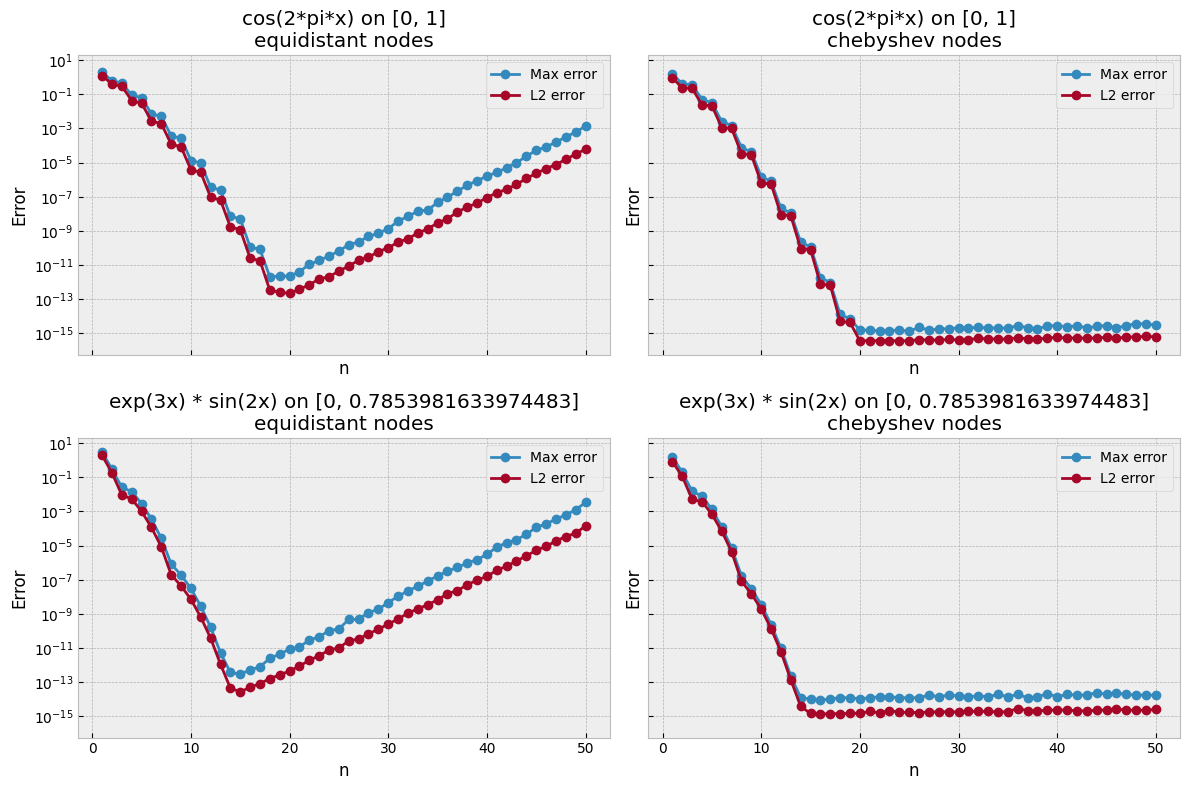

In [2]:
plot_convergence([(f_cos, 0, 1),(f_expsin, 0, np.pi/4)], 1, 50)

Our numerical results do not align with the theory we have derived. We see that the interpolation starts converging for both functions and both node types. But after a while the `Chevyshev` nodes flatten, while the `Equidistant` nodes start diverging. 
Let us specifally look at the max-norm for $\cos(2\pi x)$ and the 

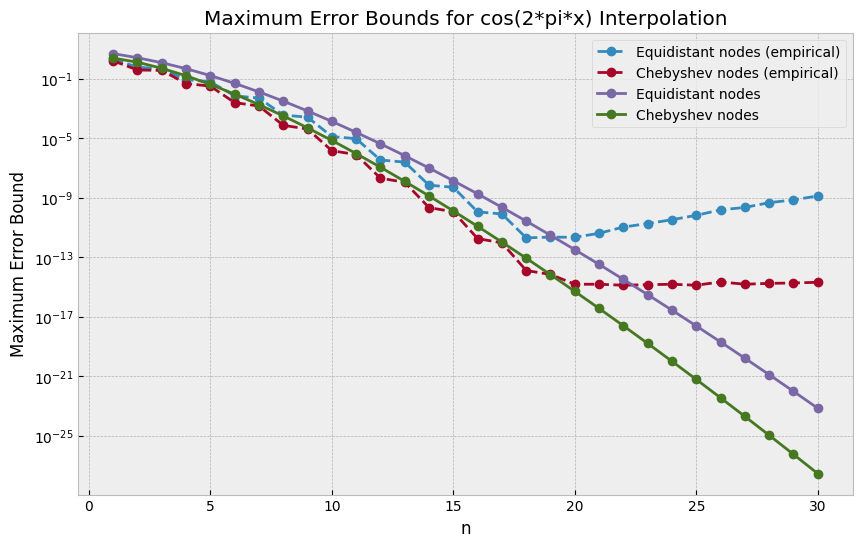

In [3]:
plot_convergece_cos_error_bound(1,30)